# Исследовательский анализ данных Olist E-commerce

В этом ноутбуке проводится исследовательский анализ данных Olist E-commerce с использованием Python.

Бизнес-показатели и агрегаты рассчитаны отдельно в SQL. Здесь основное внимание уделяется распределениям признаков, выбросам, визуальному поиску закономерностей и взаимосвязям между переменными.

Результаты EDA используются для формирования гипотез, которые будут проверены отдельно в статистическом анализе.

Основные направления:

- исследование распределений числовых признаков
- обнаружение и анализ выбросов
- визуальный анализ данных
- исследование взаимосвязей между признаками
- формирование гипотез для статистической проверки

## 1. Настройка окружения

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

In [3]:
engine = create_engine(
    "postgresql+psycopg2:///olist_analytics"
)

In [4]:
def query(sql):
    return pd.read_sql(
        text(sql),
        engine
    )

## 2. Загрузка данных

Для основного EDA формируется датасет на уровне заказа: одна строка соответствует одному заказу.

Таблицы с товарами и отзывами предварительно агрегируются до уровня `order_id`, чтобы избежать размножения строк при объединении.

Большая часть анализа распределений и взаимосвязей проводится для доставленных заказов.

In [5]:
orders = query("""
    WITH order_items_agg AS (
        SELECT
            order_id,
            COUNT(*) AS items_count,
            SUM(price)::DOUBLE PRECISION AS product_gmv,
            SUM(freight_value)::DOUBLE PRECISION AS freight_value

        FROM analytics.order_items

        GROUP BY order_id
    ),

    order_reviews AS (
        SELECT
            order_id,
            AVG(review_score::NUMERIC)::DOUBLE PRECISION
                AS avg_order_review_score

        FROM analytics.reviews

        GROUP BY order_id
    )

    SELECT
        o.order_id,
        o.order_status,
        o.order_purchase_timestamp,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date,

        c.customer_state,

        oi.items_count,
        oi.product_gmv,
        oi.freight_value,

        r.avg_order_review_score

    FROM analytics.orders AS o

    JOIN analytics.customers AS c
        USING (customer_id)

    LEFT JOIN order_items_agg AS oi
        USING (order_id)

    LEFT JOIN order_reviews AS r
        USING (order_id)
""")

In [6]:
assert len(orders) == orders["order_id"].nunique()

In [7]:
delivered_orders = (
    orders[
        orders["order_status"] == "delivered"
    ]
    .copy()
)

## 3. Подготовка признаков для EDA

Создадим дополнительные признаки, необходимые для исследования сроков и своевременности доставки.

In [8]:
# Полное время доставки:
# от оформления заказа до получения покупателем
delivered_orders["delivery_time_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# Отклонение от обещанной даты доставки.
#
# < 0  -> доставлено раньше
# = 0  -> доставлено в обещанную дату
# > 0  -> доставлено позже
delivered_orders["delivery_deviation_days"] = (
    delivered_orders["order_delivered_customer_date"].dt.normalize()
    - delivered_orders["order_estimated_delivery_date"].dt.normalize()
).dt.days

# Отношение стоимости доставки к стоимости товаров
delivered_orders["freight_to_gmv_ratio"] = (
    delivered_orders["freight_value"]
    / delivered_orders["product_gmv"].replace(0, np.nan)
)

## 4. Стоимость и состав заказа

Исследуем распределения основных характеристик доставленных заказов:

- стоимость товаров в заказе (`product_gmv`)
- количество товаров (`items_count`)
- стоимость доставки (`freight_value`)
- отношение стоимости доставки к стоимости товаров (`freight_to_gmv_ratio`)

Основное внимание уделяется форме распределений и выбросам.

In [9]:
order_features = [
    "product_gmv",
    "items_count",
    "freight_value",
    "freight_to_gmv_ratio",
]

distribution_summary = (
    delivered_orders[order_features]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)

distribution_summary

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
product_gmv,"96,478.00",137.04,209.05,0.85,45.90,86.57,149.90,269.00,399.00,990.00,"13,440.00"
items_count,"96,478.00",1.14,0.54,1.00,1.00,1.00,1.00,1.00,2.00,3.00,21.00
freight_value,"96,478.00",22.79,21.56,0.00,13.85,17.17,24.02,39.38,54.78,104.24,"1,794.96"
freight_to_gmv_ratio,"96,478.00",0.31,0.31,0.00,0.13,0.22,0.38,0.62,0.84,1.46,21.45


In [10]:
delivered_orders[order_features].skew()

product_gmv             9.89
items_count             7.56
freight_value          12.28
freight_to_gmv_ratio    9.67
dtype: float64

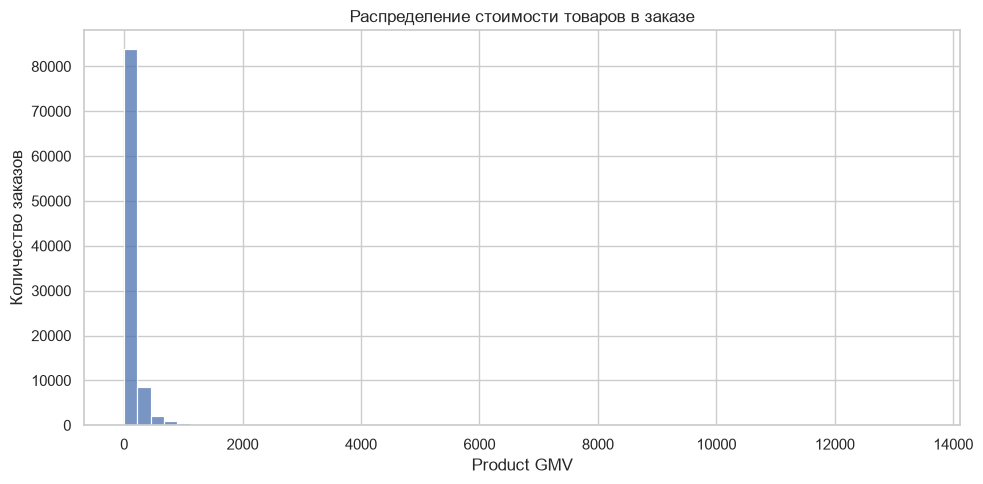

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivered_orders,
    x="product_gmv",
    bins=60,
)

plt.title("Распределение стоимости товаров в заказе")
plt.xlabel("Product GMV")
plt.ylabel("Количество заказов")

plt.tight_layout()
plt.show()

In [12]:
product_gmv_p99 = (
    delivered_orders["product_gmv"]
    .quantile(0.99)
)

product_gmv_p99

np.float64(990.0)

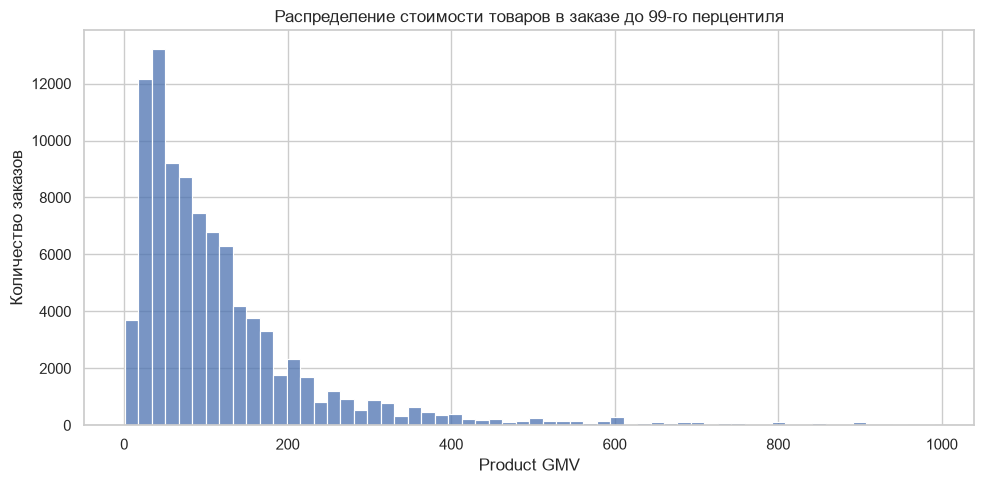

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivered_orders[
        delivered_orders["product_gmv"] <= product_gmv_p99
    ],
    x="product_gmv",
    bins=60,
)

plt.title("Распределение стоимости товаров в заказе до 99-го перцентиля")
plt.xlabel("Product GMV")
plt.ylabel("Количество заказов")

plt.tight_layout()
plt.show()

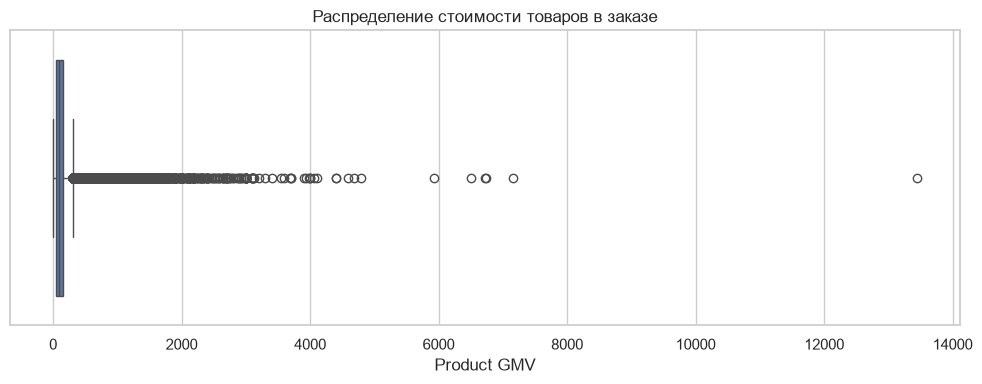

In [14]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=delivered_orders,
    x="product_gmv",
)

plt.title("Распределение стоимости товаров в заказе")
plt.xlabel("Product GMV")

plt.tight_layout()
plt.show()

In [15]:
items_distribution = (
    delivered_orders["items_count"]
    .value_counts()
    .sort_index()
)

items_distribution.head(15)

items_count
1.00     86843
2.00      7392
3.00      1306
4.00       495
5.00       193
6.00       191
7.00        22
8.00         8
9.00         3
10.00        8
11.00        4
12.00        5
13.00        1
14.00        2
15.00        2
Name: count, dtype: int64

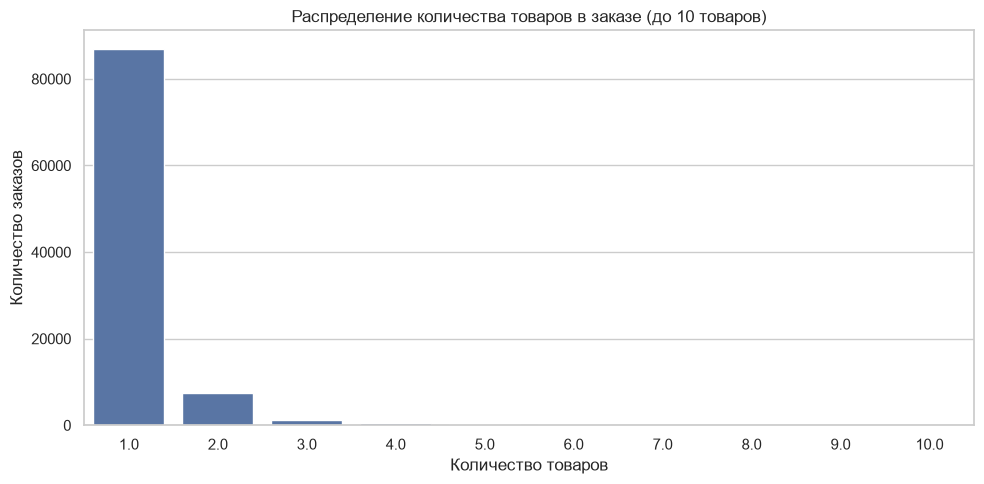

In [16]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=delivered_orders[
        delivered_orders["items_count"] <= 10
    ],
    x="items_count",
)

plt.title(
    "Распределение количества товаров в заказе "
    "(до 10 товаров)"
)
plt.xlabel("Количество товаров")
plt.ylabel("Количество заказов")

plt.tight_layout()
plt.show()

In [17]:
freight_p99 = (
    delivered_orders["freight_value"]
    .quantile(0.99)
)

freight_p99

np.float64(104.24459999999992)

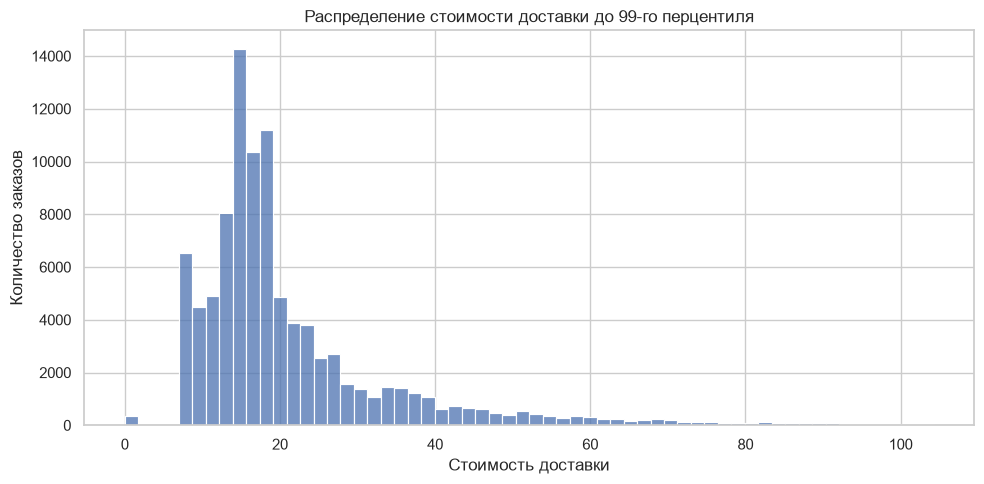

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivered_orders[
        delivered_orders["freight_value"] <= freight_p99
    ],
    x="freight_value",
    bins=60,
)

plt.title("Распределение стоимости доставки до 99-го перцентиля")
plt.xlabel("Стоимость доставки")
plt.ylabel("Количество заказов")

plt.tight_layout()
plt.show()

In [19]:
freight_ratio_p99 = (
    delivered_orders["freight_to_gmv_ratio"]
    .quantile(0.99)
)

freight_ratio_p99

np.float64(1.4585367830687808)

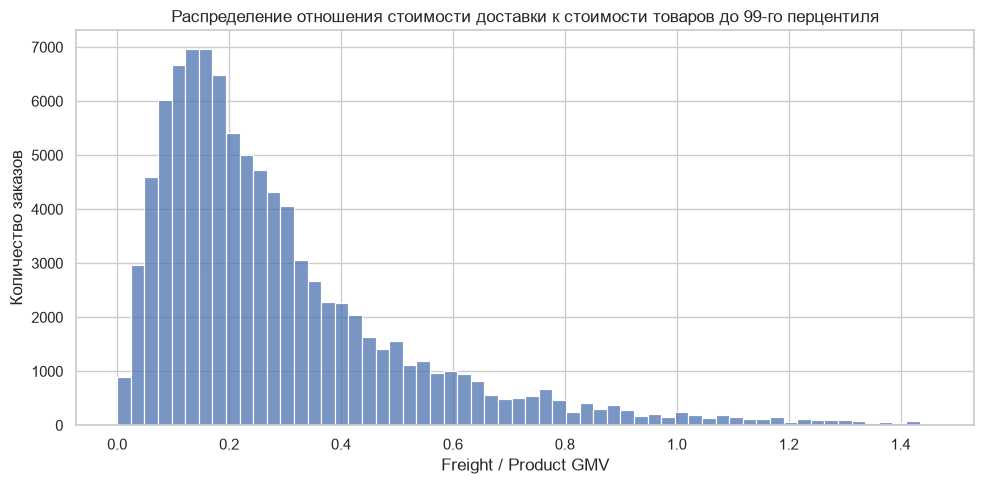

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivered_orders[
        delivered_orders["freight_to_gmv_ratio"]
        <= freight_ratio_p99
    ],
    x="freight_to_gmv_ratio",
    bins=60,
)

plt.title(
    "Распределение отношения стоимости доставки "
    "к стоимости товаров до 99-го перцентиля"
)
plt.xlabel("Freight / Product GMV")
plt.ylabel("Количество заказов")

plt.tight_layout()
plt.show()

### Исследование экстремальных значений

Распределения имеют выраженную правую асимметрию и длинные хвосты.

Экстремальные значения не удаляются автоматически, поскольку они могут отражать реальные крупные заказы или особенности стоимости доставки. Сначала рассмотрим наиболее высокие значения отдельно.

In [21]:
delivered_orders.nlargest(
    10,
    "product_gmv"
)[
    [
        "order_id",
        "product_gmv",
        "items_count",
        "freight_value",
        "freight_to_gmv_ratio",
    ]
]

,order_id,product_gmv,items_count,freight_value,freight_to_gmv_ratio
56360,03caa2c082116e1d31e67e9ae3700499,"13,440.00",8.00,224.08,0.02
33395,736e1922ae60d0d6a89247b851902527,"7,160.00",4.00,114.88,0.02
60830,0812eb902a67711a1cb742b3cdaa65ae,"6,735.00",1.00,194.31,0.03
14179,fefacc66af859508bf1a7934eab1e97f,"6,729.00",1.00,193.21,0.03
51472,f5136e38d1a14a4dbd87dff67da82701,"6,499.00",1.00,227.66,0.04
16143,2cc9089445046817a7539d90805e6e5a,"5,934.60",6.00,146.94,0.02
26710,a96610ab360d42a2e5335a3998b4718a,"4,799.00",1.00,151.34,0.03
69917,199af31afc78c699f0dbf71fb178d4d4,"4,690.00",1.00,74.34,0.02
69922,8dbc85d1447242f3b127dda390d56e19,"4,590.00",1.00,91.78,0.02
55070,d2f270487125ddc41fd134c4003ad1d7,"4,400.00",2.00,45.50,0.01


In [22]:
delivered_orders.nlargest(
    10,
    "items_count"
)[
    [
        "order_id",
        "items_count",
        "product_gmv",
        "freight_value",
    ]
]

,order_id,items_count,product_gmv,freight_value
44502,8272b63d03f5f79c56e9e4120aec44ef,21.00,31.80,164.37
47062,ab14fdcfbe524636d65ee38360e22ce8,20.00,"1,974.00",288.80
93182,1b15974a0141d54e36626dca3fdc731a,20.00,"2,000.00",202.40
64919,428a2f660dc84138d969ccd69a0ab6d5,15.00,982.35,243.30
82872,9ef13efd6949e4573a18964dd1bbe7f5,15.00,765.00,18.00
63435,73c8ab38f07dc94389065f7eba4f297a,14.00,826.00,188.02
63559,9bdc4d4c71aa1de4606060929dee888c,14.00,419.86,108.92
73710,37ee401157a3a0b28c9c6d0ed8c3b24b,13.00,389.87,96.07
39099,c05d6a79e55da72ca780ce90364abed9,12.00,213.84,88.68
45036,af822dacd6f5cff7376413c03a388bb7,12.00,61.26,182.76


In [23]:
delivered_orders.nlargest(
    10,
    "freight_value"
)[
    [
        "order_id",
        "product_gmv",
        "items_count",
        "freight_value",
        "freight_to_gmv_ratio",
    ]
]

,order_id,product_gmv,items_count,freight_value,freight_to_gmv_ratio
10067,cf4659487be50c0c317cff3564c4a840,"1,050.00",6.00,"1,794.96",1.71
31901,2455cbeb73fd04b170ca2504662f95ce,419.40,6.00,"1,002.29",2.39
94059,cfed507ac357129f750f05a0d7d71b15,"1,380.00",3.00,711.33,0.52
57853,71dab1155600756af6de79de92e712e3,"1,361.89",11.00,626.64,0.46
14000,17784b9fbb37fb0bdc230d8ed6f6b355,840.00,6.00,502.98,0.60
93198,725cf8e9c24e679a8a5a32cb92c9ce1e,"1,570.00",2.00,497.42,0.32
9460,5bd06bab48e0423fc35d1c236d48a6bb,"1,520.00",2.00,497.08,0.33
59941,be382a9e1ed25128148b97d6bfdb21af,"1,559.92",8.00,479.28,0.31
61395,c52c7fbe316b5b9d549e8a25206b8a1f,"1,161.00",9.00,458.73,0.40
99167,62073ec6b54b8e6322037fc0f3591ad3,859.66,7.00,456.47,0.53


In [24]:
delivered_orders.nlargest(
    10,
    "freight_to_gmv_ratio"
)[
    [
        "order_id",
        "product_gmv",
        "freight_value",
        "freight_to_gmv_ratio",
        "customer_state",
    ]
]

,order_id,product_gmv,freight_value,freight_to_gmv_ratio,customer_state
41747,6e864b3f0ec71031117ad4cf46b7f2a1,0.85,18.23,21.45,RJ
85264,3ee6513ae7ea23bdfab5b9ab60bffcb5,0.85,18.23,21.45,SP
42291,7c92284adbec8033d160303d83065dbf,9.18,54.69,5.96,RS
57235,b2d30dfaf7114de8ab3f737d062032fe,5.95,34.15,5.74,BA
37133,21fb84496c034392ca2aafe7f7919a3f,6.99,37.90,5.42,PE
91423,a16607f4220f0e60ab4c71b915dd380c,14.00,74.08,5.29,SC
13162,95d6357ffe41aa6d2998852a710c70a0,17.50,91.15,5.21,PR
44502,8272b63d03f5f79c56e9e4120aec44ef,31.80,164.37,5.17,SP
43512,f9ccaff7267fd0cf076e795b1fae8b69,3.00,15.23,5.08,RJ
77980,3aa41f0c241b0ef62147d849b02313be,4.90,24.84,5.07,PB


In [25]:
for column in [
    "product_gmv",
    "freight_value",
    "freight_to_gmv_ratio",
]:
    threshold = delivered_orders[column].quantile(0.99)

    count = (
        delivered_orders[column] > threshold
    ).sum()

    print(
        f"{column}: "
        f"p99 = {threshold:.2f}, "
        f"observations above p99 = {count}"
    )

product_gmv: p99 = 990.00, observations above p99 = 964
freight_value: p99 = 104.24, observations above p99 = 965
freight_to_gmv_ratio: p99 = 1.46, observations above p99 = 965


### Наблюдения

- Все исследованные показатели имеют выраженную правую асимметрию и длинные хвосты.
- Большинство заказов имеют относительно небольшую стоимость: 99% заказов имеют `product_gmv` не выше 990, тогда как максимальное значение достигает 13 440.
- Большинство заказов состоят из одного товара; заказы с большим количеством позиций встречаются редко.
- Для стоимости доставки также характерен длинный правый хвост: отдельные значения значительно превышают основную массу наблюдений.
- Высокие значения `freight_to_gmv_ratio` в основном наблюдаются у заказов с очень низкой стоимостью товаров. Это указывает на потенциальную обратную связь между стоимостью товаров в заказе и относительной стоимостью доставки.
- Экстремальные значения не удаляются, так как на данном этапе нет оснований считать их ошибками данных.

## 5. Доставка

Исследуем распределение времени доставки и отклонения фактической даты доставки от ожидаемой.

Бизнес-показатели доставки уже рассчитаны в SQL, поэтому здесь основное внимание уделяется форме распределений, хвостам и экстремальным наблюдениям.

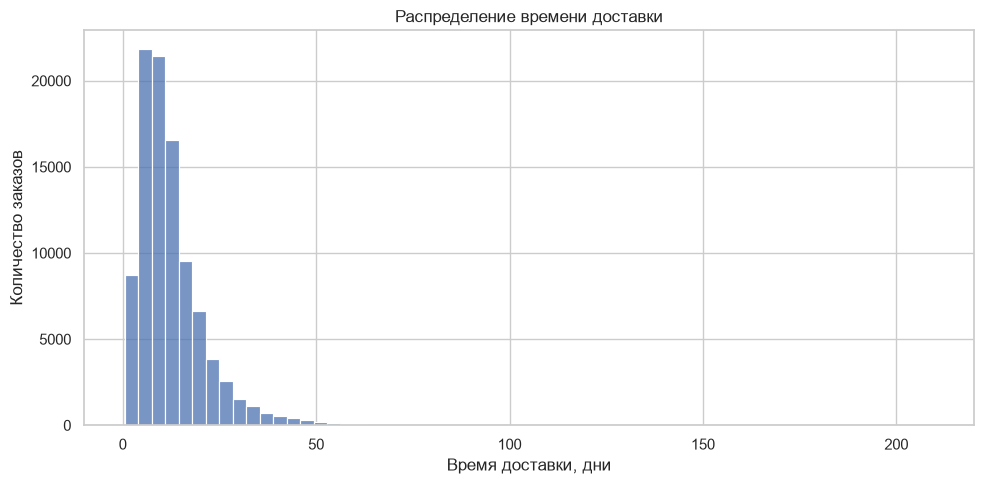

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivered_orders,
    x="delivery_time_days",
    bins=60,
)

plt.title("Распределение времени доставки")
plt.xlabel("Время доставки, дни")
plt.ylabel("Количество заказов")

plt.tight_layout()
plt.show()

In [27]:
delivery_time_p99 = (
    delivered_orders["delivery_time_days"]
    .quantile(0.99)
)

delivery_time_p99

np.float64(46.05026180555554)

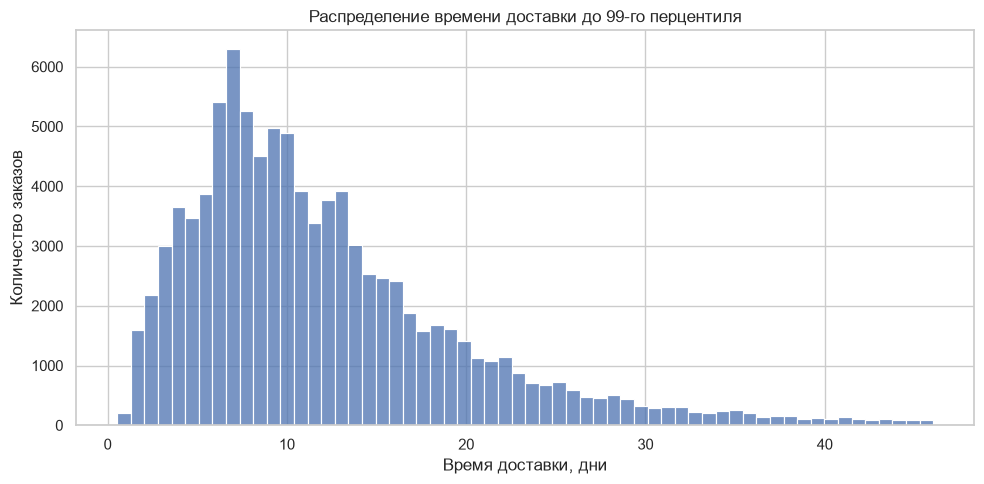

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivered_orders[
        delivered_orders["delivery_time_days"]
        <= delivery_time_p99
    ],
    x="delivery_time_days",
    bins=60,
)

plt.title("Распределение времени доставки до 99-го перцентиля")
plt.xlabel("Время доставки, дни")
plt.ylabel("Количество заказов")

plt.tight_layout()
plt.show()

In [29]:
deviation_p01 = (
    delivered_orders["delivery_deviation_days"]
    .quantile(0.01)
)

deviation_p99 = (
    delivered_orders["delivery_deviation_days"]
    .quantile(0.99)
)

deviation_p01, deviation_p99

(np.float64(-36.0), np.float64(18.0))

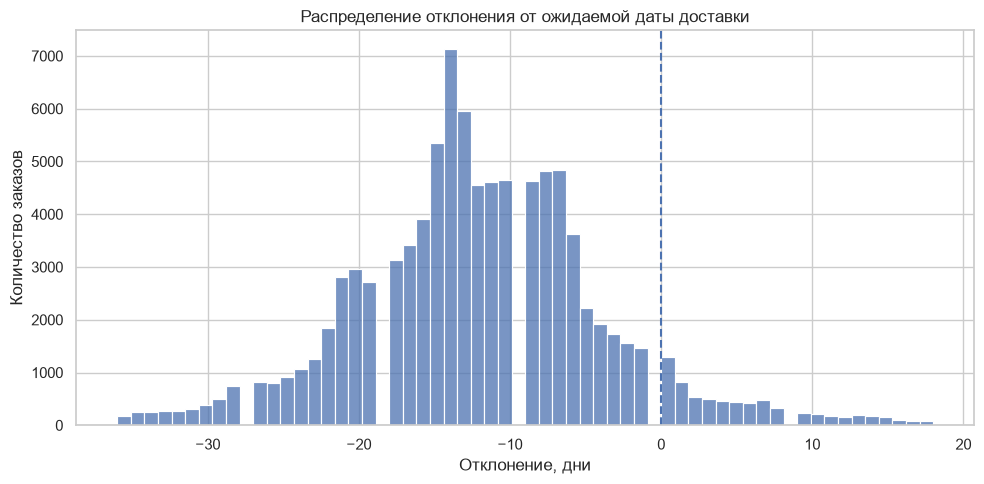

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivered_orders[
        delivered_orders["delivery_deviation_days"]
        .between(
            deviation_p01,
            deviation_p99
        )
    ],
    x="delivery_deviation_days",
    bins=60,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.title(
    "Распределение отклонения "
    "от ожидаемой даты доставки"
)
plt.xlabel("Отклонение, дни")
plt.ylabel("Количество заказов")

plt.tight_layout()
plt.show()

In [31]:
delivered_orders.nlargest(
    10,
    "delivery_time_days"
)[
    [
        "order_id",
        "customer_state",
        "delivery_time_days",
        "delivery_deviation_days",
        "product_gmv",
        "freight_value",
        "avg_order_review_score",
    ]
]

,order_id,customer_state,delivery_time_days,delivery_deviation_days,product_gmv,freight_value,avg_order_review_score
9809,ca07593549f1816d26a572e06dc1eab6,ES,209.63,181.00,229.90,15.78,NaN
77512,1b3190b2dfa9d789e1f14c05b647a14a,RJ,208.35,188.00,144.99,17.26,2.00
30864,440d0d17af552815d15a9e41abe49359,PA,195.63,165.00,159.90,25.12,1.00
35183,2fb597c2f772eca01b1f5c561bf6cc7b,PI,194.85,155.00,239.96,105.19,4.00
94235,285ab9426d6982034523a855f55a885e,SE,194.63,166.00,429.90,27.75,1.00
19269,0f4519c5f1c541ddec9f21b3bddd533a,PI,194.05,161.00,231.27,27.88,4.00
55376,47b40429ed8cce3aee9199792275433f,SP,191.46,175.00,399.00,54.33,1.00
40824,2fe324febf907e3ea3f2aa9650869fa5,SP,189.86,167.00,39.90,16.05,1.00
27251,2d7561026d542c8dbd8f0daeadf67a43,SE,188.13,159.00,32.90,20.80,3.00
84095,c27815f7e3dd0b926b58552628481575,MG,187.74,162.00,487.00,48.90,3.00


In [32]:
delivered_orders.nlargest(
    10,
    "delivery_deviation_days"
)[
    [
        "order_id",
        "customer_state",
        "delivery_time_days",
        "delivery_deviation_days",
        "product_gmv",
        "freight_value",
        "avg_order_review_score",
    ]
]

,order_id,customer_state,delivery_time_days,delivery_deviation_days,product_gmv,freight_value,avg_order_review_score
77512,1b3190b2dfa9d789e1f14c05b647a14a,RJ,208.35,188.00,144.99,17.26,2.00
9809,ca07593549f1816d26a572e06dc1eab6,ES,209.63,181.00,229.90,15.78,NaN
55376,47b40429ed8cce3aee9199792275433f,SP,191.46,175.00,399.00,54.33,1.00
40824,2fe324febf907e3ea3f2aa9650869fa5,SP,189.86,167.00,39.90,16.05,1.00
94235,285ab9426d6982034523a855f55a885e,SE,194.63,166.00,429.90,27.75,1.00
30864,440d0d17af552815d15a9e41abe49359,PA,195.63,165.00,159.90,25.12,1.00
84095,c27815f7e3dd0b926b58552628481575,MG,187.74,162.00,487.00,48.90,3.00
19269,0f4519c5f1c541ddec9f21b3bddd533a,PI,194.05,161.00,231.27,27.88,4.00
70156,d24e8541128cea179a11a65176e0a96f,SP,175.22,161.00,39.98,23.46,4.00
27251,2d7561026d542c8dbd8f0daeadf67a43,SE,188.13,159.00,32.90,20.80,3.00


### Наблюдения

- Распределение времени доставки имеет длинный правый хвост: 99% доставок занимают не более примерно 46 дней, однако отдельные заказы доставлялись более 180–200 дней.
- Центральные 98% наблюдений находятся примерно в диапазоне от 36 дней раньше до 18 дней позже ожидаемой даты доставки.
- Наиболее продолжительные доставки в значительной степени совпадают с наиболее сильными опозданиями: максимальные отклонения от ожидаемой даты превышают 150 дней.
- Среди заказов с экстремальными задержками часто встречаются низкие оценки, однако присутствуют и высокие оценки, поэтому по отдельным наблюдениям нельзя делать вывод о статистической связи.
- Экстремальные задержки встречаются в разных штатах, поэтому по этим наблюдениям нельзя связать их с одним конкретным регионом.

## 6. Отзывы

Исследуем распределение оценок отзывов для доставленных заказов и наличие текстовых комментариев.

В этом разделе используется уровень отдельного отзыва: одна строка соответствует одной записи из таблицы `reviews`.

На этом этапе рассматривается структура данных и визуальные закономерности. Связь оценки заказа с характеристиками заказа и доставки будет исследована отдельно на уровне заказа.

In [33]:
reviews = query("""
    SELECT
        r.order_id,
        r.review_id,
        r.review_score,

        (
            NULLIF(
                BTRIM(r.review_comment_message),
                ''
            ) IS NOT NULL
        ) AS has_comment

    FROM analytics.reviews AS r

    JOIN analytics.orders AS o
        USING (order_id)

    WHERE o.order_status = 'delivered'
""")

In [34]:
review_score_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="reviews_count")
)

review_score_distribution

,review_score,reviews_count
0,1,9406
1,2,2941
2,3,7961
3,4,18987
4,5,57066


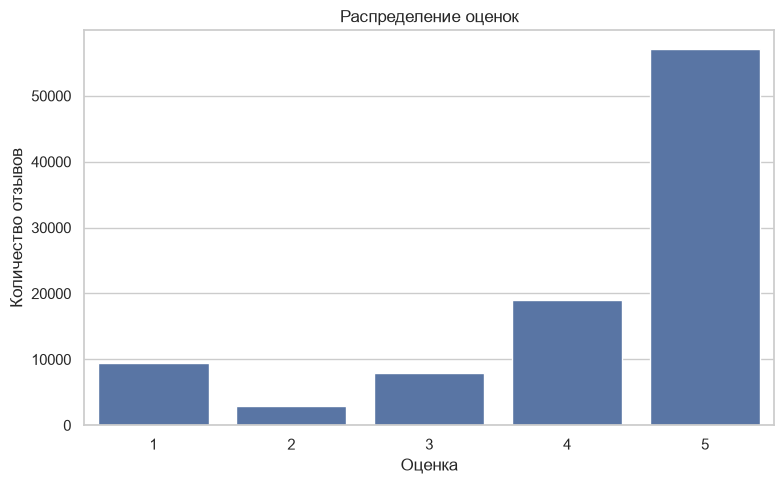

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews,
    x="review_score",
)

plt.title("Распределение оценок")
plt.xlabel("Оценка")
plt.ylabel("Количество отзывов")

plt.tight_layout()
plt.show()

In [36]:
comment_by_score = (
    reviews
    .groupby(
        "review_score",
        as_index=False
    )
    .agg(
        reviews_count=("review_id", "count"),
        comments_count=("has_comment", "sum"),
        comment_rate=("has_comment", "mean"),
    )
)

comment_by_score["comment_rate"] *= 100

comment_by_score

,review_score,reviews_count,comments_count,comment_rate
0,1,9406,7290,77.50
1,2,2941,1994,67.80
2,3,7961,3449,43.32
3,4,18987,5915,31.15
4,5,57066,20442,35.82


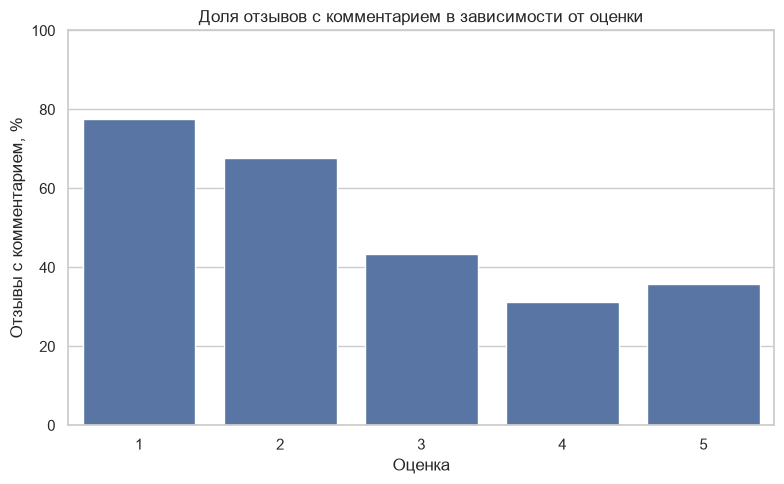

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comment_by_score,
    x="review_score",
    y="comment_rate",
)

plt.title(
    "Доля отзывов с комментарием "
    "в зависимости от оценки"
)

plt.xlabel("Оценка")
plt.ylabel("Отзывы с комментарием, %")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Наблюдения

- В распределении отзывов преобладают высокие оценки: наиболее часто встречается оценка 5.
- Отзывы с низкой оценкой значительно чаще содержат текстовый комментарий.
- Для оценки 1 комментарий присутствует примерно в 78% отзывов, тогда как для оценок 4 и 5 — примерно в 31% и 36% соответственно.
- Это может указывать на то, что низкие оценки чаще сопровождаются дополнительным текстовым комментарием.

## 7. Взаимосвязи между признаками

На этом этапе исследуем возможные связи между характеристиками заказа, стоимостью доставки и качеством доставки.

Цель раздела — обнаружить визуальные закономерности и сформировать кандидаты на гипотезы для последующего статистического анализа.

In [38]:
plot_sample = delivered_orders.sample(
    n=5000,
    random_state=42
).copy()

plot_sample["log_product_gmv"] = np.log1p(
    plot_sample["product_gmv"]
)

plot_sample["log_freight_value"] = np.log1p(
    plot_sample["freight_value"]
)

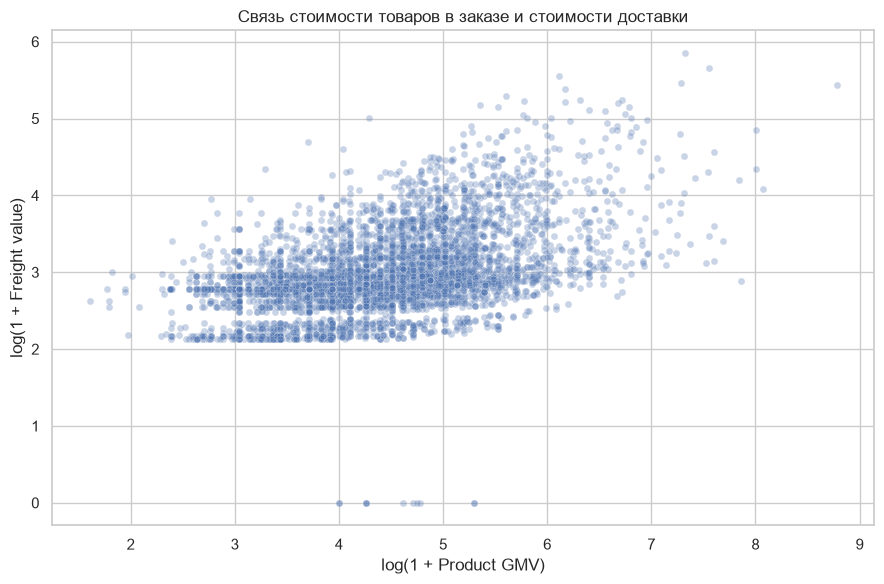

In [39]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=plot_sample,
    x="log_product_gmv",
    y="log_freight_value",
    alpha=0.3,
    s=25,
)

plt.title(
    "Связь стоимости товаров в заказе "
    "и стоимости доставки"
)
plt.xlabel("log(1 + Product GMV)")
plt.ylabel("log(1 + Freight value)")

plt.tight_layout()
plt.show()

In [40]:
gmv_p99 = (
    delivered_orders["product_gmv"]
    .quantile(0.99)
)

ratio_p99 = (
    delivered_orders["freight_to_gmv_ratio"]
    .quantile(0.99)
)

freight_ratio_plot = delivered_orders[
    (delivered_orders["product_gmv"] <= gmv_p99)
    & (
        delivered_orders["freight_to_gmv_ratio"]
        <= ratio_p99
    )
]

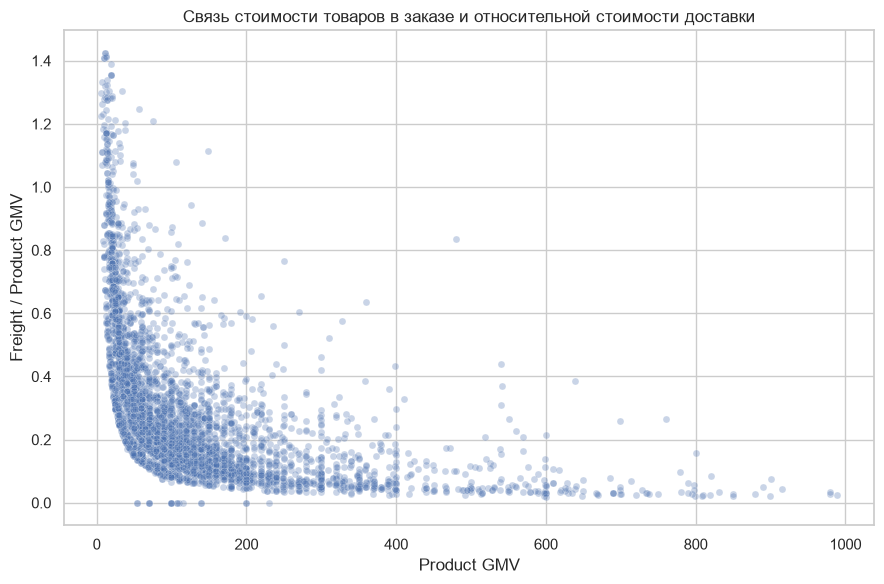

In [41]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=freight_ratio_plot.sample(
        n=min(5000, len(freight_ratio_plot)),
        random_state=42,
    ),
    x="product_gmv",
    y="freight_to_gmv_ratio",
    alpha=0.3,
    s=25,
)

plt.title(
    "Связь стоимости товаров в заказе "
    "и относительной стоимости доставки"
)
plt.xlabel("Product GMV")
plt.ylabel("Freight / Product GMV")

plt.tight_layout()
plt.show()

In [42]:
delivery_reviews = (
    delivered_orders[
        delivered_orders[
            [
                "delivery_time_days",
                "delivery_deviation_days",
                "avg_order_review_score",
            ]
        ]
        .notna()
        .all(axis=1)
    ]
    .copy()
)

Для категориальной визуализации используются заказы с целыми значениями средней оценки. Редкие дробные значения, возникающие при наличии нескольких отзывов на один заказ, исключаются только из boxplot и сохраняются в корреляционном анализе.

In [43]:
delivery_reviews_integer = (
    delivery_reviews[
        delivery_reviews["avg_order_review_score"]
        .isin([1, 2, 3, 4, 5])
    ]
    .copy()
)

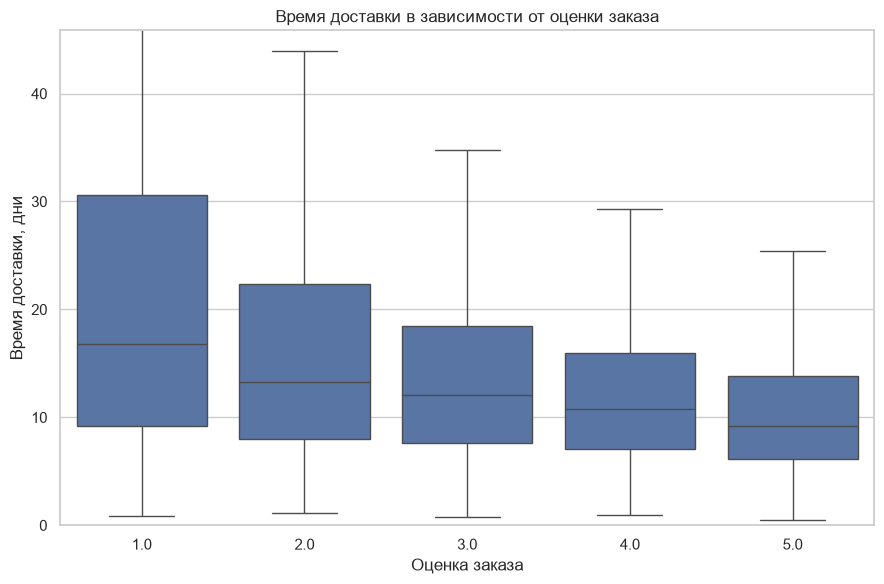

In [44]:
delivery_p99 = (
    delivery_reviews_integer["delivery_time_days"]
    .quantile(0.99)
)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=delivery_reviews_integer,
    x="avg_order_review_score",
    y="delivery_time_days",
    showfliers=False,
)

plt.ylim(0, delivery_p99)

plt.title(
    "Время доставки в зависимости от оценки заказа"
)
plt.xlabel("Оценка заказа")
plt.ylabel("Время доставки, дни")

plt.tight_layout()
plt.show()

In [45]:
deviation_low = (
    delivery_reviews_integer[
        "delivery_deviation_days"
    ].quantile(0.01)
)

deviation_high = (
    delivery_reviews_integer[
        "delivery_deviation_days"
    ].quantile(0.99)
)

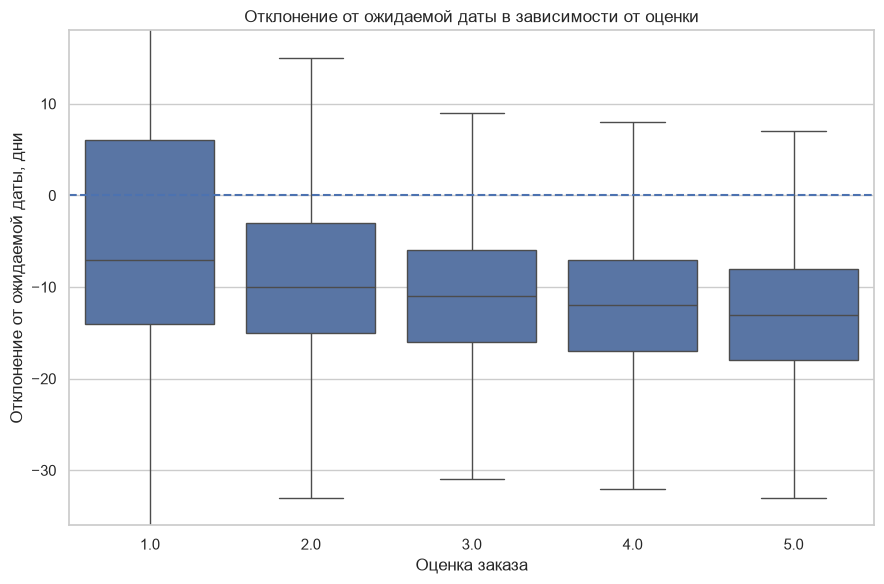

In [46]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=delivery_reviews_integer,
    x="avg_order_review_score",
    y="delivery_deviation_days",
    showfliers=False,
)

plt.ylim(
    deviation_low,
    deviation_high,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.title(
    "Отклонение от ожидаемой даты "
    "в зависимости от оценки"
)
plt.xlabel("Оценка заказа")
plt.ylabel("Отклонение от ожидаемой даты, дни")

plt.tight_layout()
plt.show()

In [47]:
correlation_features = [
    "product_gmv",
    "items_count",
    "freight_value",
    "delivery_time_days",
    "delivery_deviation_days",
    "avg_order_review_score",
]

spearman_corr = (
    delivered_orders[
        correlation_features
    ]
    .corr(method="spearman")
)

spearman_corr

,product_gmv,items_count,freight_value,delivery_time_days,delivery_deviation_days,avg_order_review_score
product_gmv,1.00,0.18,0.47,0.10,-0.04,-0.03
items_count,0.18,1.00,0.38,-0.03,-0.04,-0.11
freight_value,0.47,0.38,1.00,0.38,-0.16,-0.09
delivery_time_days,0.10,-0.03,0.38,1.00,0.31,-0.23
delivery_deviation_days,-0.04,-0.04,-0.16,0.31,1.00,-0.18
avg_order_review_score,-0.03,-0.11,-0.09,-0.23,-0.18,1.00


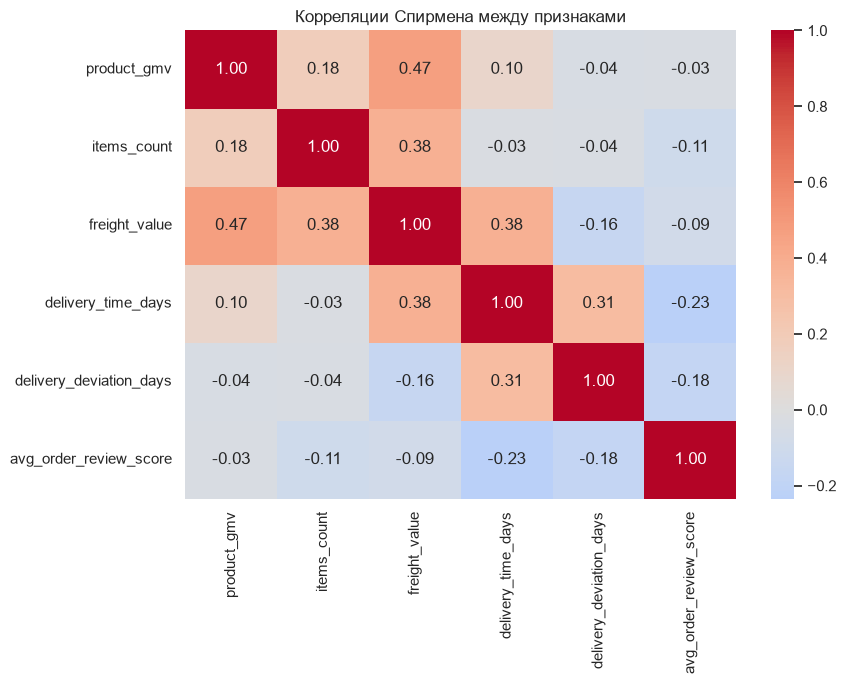

In [48]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Корреляции Спирмена между признаками")

plt.tight_layout()
plt.show()

### Наблюдения

- Стоимость товаров в заказе положительно связана со стоимостью доставки: более дорогие заказы в среднем сопровождаются более высокой абсолютной стоимостью доставки.
- Относительная стоимость доставки особенно велика для дешёвых заказов и быстро снижается с ростом стоимости товаров. При интерпретации этой зависимости необходимо учитывать, что `product_gmv` входит в знаменатель `freight_to_gmv_ratio`.
- Более низкие оценки связаны с более продолжительной доставкой. На boxplot медианное время доставки последовательно уменьшается при переходе от низких оценок к высоким.
- Аналогичная закономерность наблюдается для отклонения от ожидаемой даты: у заказов с низкими оценками распределение `delivery_deviation_days` смещено в сторону более поздней доставки относительно обещанного срока.
- Корреляция Спирмена между временем доставки и оценкой заказа составляет около -0.23, а между отклонением от ожидаемой даты и оценкой — около -0.18. Связи не являются сильными, но достаточно заметны для дальнейшей статистической проверки.
- Стоимость доставки умеренно связана со временем доставки, однако эта связь может зависеть от географии заказа и требует дополнительного исследования.

## 8. Географическое расстояние и доставка

Исследуем, связано ли приблизительное расстояние между покупателем и продавцом со стоимостью и временем доставки.

Координаты соответствуют ZIP-префиксам покупателей и продавцов. Расстояние рассчитывается приблизительно по большой окружности Земли между агрегированными ZIP-координатами и не соответствует фактической длине маршрута доставки.

Для анализа стоимости доставки используется уровень `order_id × seller_id`, поскольку один заказ может содержать товары нескольких продавцов.

In [49]:
order_seller_geo = query("""
    WITH order_seller_metrics AS (
        SELECT
            order_id,
            seller_id,

            SUM(freight_value)::DOUBLE PRECISION
                AS pair_freight_value

        FROM analytics.order_items

        GROUP BY
            order_id,
            seller_id
    )

    SELECT
        osm.order_id,
        osm.seller_id,
        osm.pair_freight_value,

        c.customer_state,
        s.seller_state,

        customer_geo.geolocation_state
            AS customer_geo_state,

        seller_geo.geolocation_state
            AS seller_geo_state,

        customer_geo.geolocation_lat
            AS customer_lat,

        customer_geo.geolocation_lng
            AS customer_lng,

        seller_geo.geolocation_lat
            AS seller_lat,

        seller_geo.geolocation_lng
            AS seller_lng

    FROM order_seller_metrics AS osm

    JOIN analytics.orders AS o
        USING (order_id)

    JOIN analytics.customers AS c
        USING (customer_id)

    JOIN analytics.sellers AS s
        USING (seller_id)

    LEFT JOIN analytics.geolocation AS customer_geo
        ON c.customer_zip_code_prefix =
           customer_geo.geolocation_zip_code_prefix

    LEFT JOIN analytics.geolocation AS seller_geo
        ON s.seller_zip_code_prefix =
           seller_geo.geolocation_zip_code_prefix

    WHERE o.order_status = 'delivered'
""")

In [50]:
assert not order_seller_geo.duplicated(
    ["order_id", "seller_id"]
).any()

In [51]:
geo_pairs = (
    order_seller_geo
    .dropna(
        subset=[
            "customer_lat",
            "customer_lng",
            "seller_lat",
            "seller_lng",
            "customer_geo_state",
            "seller_geo_state",
        ]
    )
    .copy()
)

geo_pairs = geo_pairs[
    # ZIP покупателя должен соответствовать
    # тому же штату, что указан в customers.
    geo_pairs["customer_state"].eq(
        geo_pairs["customer_geo_state"]
    )

    # ZIP продавца должен соответствовать
    # тому же штату, что указан в sellers.
    & geo_pairs["seller_state"].eq(
        geo_pairs["seller_geo_state"]
    )

    # Дополнительно исключаем координаты,
    # явно находящиеся за пределами Бразилии.
    & geo_pairs["customer_lat"].between(-34, 6)
    & geo_pairs["customer_lng"].between(-74, -28)

    & geo_pairs["seller_lat"].between(-34, 6)
    & geo_pairs["seller_lng"].between(-74, -28)
].copy()

In [52]:
geo_filter_summary = pd.Series({
    "all_order_seller_pairs":
        len(order_seller_geo),

    "valid_geo_pairs":
        len(geo_pairs),

    "excluded_pairs":
        len(order_seller_geo)
        - len(geo_pairs),

    "coverage_pct":
        (
            len(geo_pairs)
            / len(order_seller_geo)
            * 100
        ),
})

geo_filter_summary

all_order_seller_pairs   97,819.00
valid_geo_pairs          96,754.00
excluded_pairs            1,065.00
coverage_pct                 98.91
dtype: float64

In [53]:
customer_lat = np.radians(
    geo_pairs["customer_lat"]
)

customer_lng = np.radians(
    geo_pairs["customer_lng"]
)

seller_lat = np.radians(
    geo_pairs["seller_lat"]
)

seller_lng = np.radians(
    geo_pairs["seller_lng"]
)

In [54]:
cos_angle = (
    np.sin(customer_lat)
    * np.sin(seller_lat)
    +
    np.cos(customer_lat)
    * np.cos(seller_lat)
    * np.cos(
        seller_lng - customer_lng
    )
)

geo_pairs["distance_km"] = (
    6371
    * np.arccos(
        np.clip(
            cos_angle,
            -1,
            1,
        )
    )
)

In [55]:
geo_pairs["distance_km"].describe(
    percentiles=[
        0.50,
        0.90,
        0.95,
        0.99,
    ]
)

count   96,754.00
mean       599.68
std        591.74
min          0.00
50%        433.34
90%      1,455.90
95%      2,093.83
99%      2,481.75
max      3,710.42
Name: distance_km, dtype: float64

In [56]:
distance_p99 = (
    geo_pairs["distance_km"]
    .quantile(0.99)
)

pair_freight_p99 = (
    geo_pairs["pair_freight_value"]
    .quantile(0.99)
)

In [57]:
distance_freight_plot = geo_pairs[
    (geo_pairs["distance_km"] <= distance_p99)
    & (
        geo_pairs["pair_freight_value"]
        <= pair_freight_p99
    )
]

In [58]:
distance_freight_sample = (
    distance_freight_plot
    .sample(
        n=min(
            5000,
            len(distance_freight_plot),
        ),
        random_state=42,
    )
)

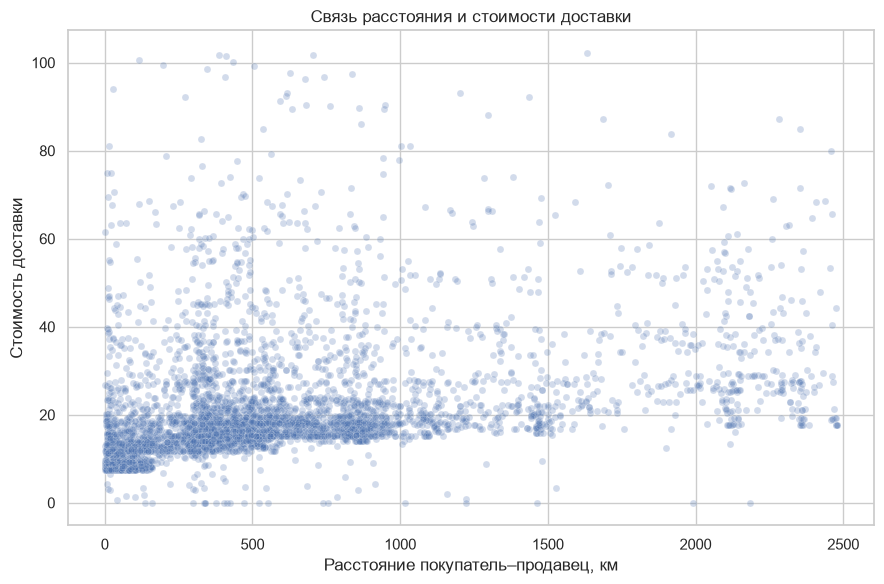

In [59]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=distance_freight_sample,
    x="distance_km",
    y="pair_freight_value",
    alpha=0.25,
    s=25,
)

plt.title(
    "Связь расстояния и стоимости доставки"
)
plt.xlabel("Расстояние покупатель–продавец, км")
plt.ylabel("Стоимость доставки")

plt.tight_layout()
plt.show()

In [60]:
distance_freight_corr = (
    geo_pairs[
        [
            "distance_km",
            "pair_freight_value",
        ]
    ]
    .corr(method="spearman")
    .loc[
        "distance_km",
        "pair_freight_value",
    ]
)

distance_freight_corr

np.float64(0.5816623243016443)

In [61]:
distance_p99 = (
    geo_pairs["distance_km"]
    .quantile(0.99)
)

geo_pairs_p99 = geo_pairs[
    geo_pairs["distance_km"]
    <= distance_p99
]

distance_freight_corr_p99 = (
    geo_pairs_p99[
        [
            "distance_km",
            "pair_freight_value",
        ]
    ]
    .corr(method="spearman")
    .loc[
        "distance_km",
        "pair_freight_value",
    ]
)

In [62]:
all_pairs_per_order = (
    order_seller_geo
    .groupby("order_id")
    .size()
    .rename("all_pairs")
)

valid_pairs_per_order = (
    geo_pairs
    .groupby("order_id")
    .size()
    .rename("valid_pairs")
)

geo_order_coverage = (
    pd.concat(
        [
            all_pairs_per_order,
            valid_pairs_per_order,
        ],
        axis=1,
    )
    .fillna(0)
)

complete_geo_order_ids = (
    geo_order_coverage[
        geo_order_coverage["all_pairs"]
        == geo_order_coverage["valid_pairs"]
    ]
    .index
)

In [63]:
order_geo_summary = pd.Series({
    "orders_with_seller_pairs":
        len(all_pairs_per_order),

    "orders_with_complete_geo":
        len(complete_geo_order_ids),

    "excluded_orders":
        (
            len(all_pairs_per_order)
            - len(complete_geo_order_ids)
        ),

    "coverage_pct":
        (
            len(complete_geo_order_ids)
            / len(all_pairs_per_order)
            * 100
        ),
})

order_geo_summary

orders_with_seller_pairs   96,478.00
orders_with_complete_geo   95,419.00
excluded_orders             1,059.00
coverage_pct                   98.90
dtype: float64

### Расстояние на уровне заказа

Для анализа времени доставки необходимо перейти от уровня `order_id × seller_id` к уровню заказа.

В качестве исследовательского показателя используется расстояние до наиболее удалённого продавца (`max_seller_distance_km`). Для заказов с несколькими продавцами такой показатель отражает наиболее удалённую точку отправления и используется как приближённый proxy географической сложности заказа.

В анализ включаются только заказы, для которых доступны валидные координаты всех продавцов.

In [64]:
order_distance = (
    geo_pairs[
        geo_pairs["order_id"].isin(
            complete_geo_order_ids
        )
    ]
    .groupby(
        "order_id",
        as_index=False,
    )
    .agg(
        max_seller_distance_km=(
            "distance_km",
            "max",
        ),
    )
)

In [65]:
distance_delivery = (
    order_distance
    .merge(
        delivered_orders[
            [
                "order_id",
                "delivery_time_days",
                "delivery_deviation_days",
            ]
        ],
        on="order_id",
        how="inner",
        validate="1:1",
    )
)

In [66]:
distance_order_p99 = (
    distance_delivery[
        "max_seller_distance_km"
    ]
    .quantile(0.99)
)

delivery_p99 = (
    distance_delivery[
        "delivery_time_days"
    ]
    .quantile(0.99)
)

In [67]:
distance_delivery_plot = (
    distance_delivery[
        (
            distance_delivery[
                "max_seller_distance_km"
            ]
            <= distance_order_p99
        )
        &
        (
            distance_delivery[
                "delivery_time_days"
            ]
            <= delivery_p99
        )
    ]
)

In [68]:
distance_delivery_sample = (
    distance_delivery_plot
    .sample(
        n=min(
            5000,
            len(distance_delivery_plot),
        ),
        random_state=42,
    )
)

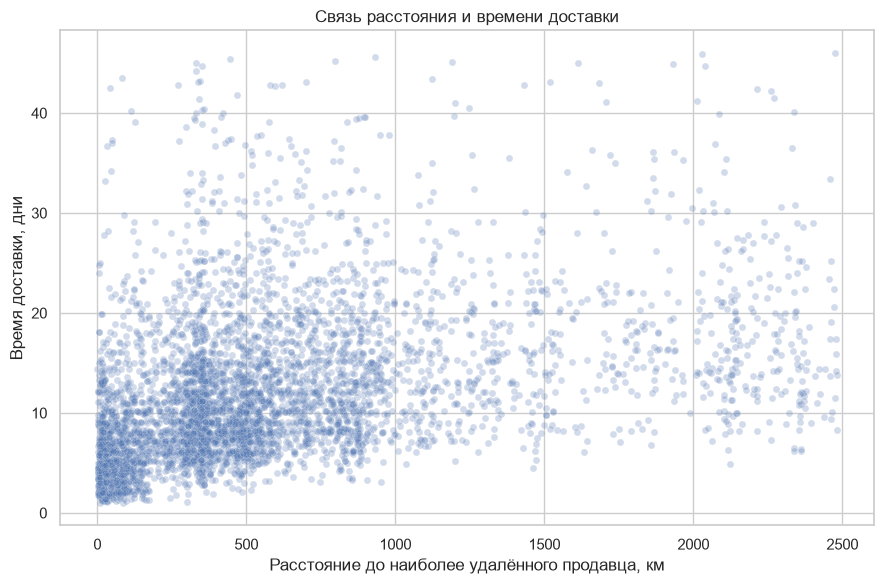

In [69]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=distance_delivery_sample,
    x="max_seller_distance_km",
    y="delivery_time_days",
    alpha=0.25,
    s=25,
)

plt.title(
    "Связь расстояния и времени доставки"
)
plt.xlabel(
    "Расстояние до наиболее удалённого продавца, км"
)
plt.ylabel("Время доставки, дни")

plt.tight_layout()
plt.show()

In [70]:
distance_deviation_corr = (
    distance_delivery[
        [
            "max_seller_distance_km",
            "delivery_deviation_days",
        ]
    ]
    .corr(method="spearman")
    .loc[
        "max_seller_distance_km",
        "delivery_deviation_days",
    ]
)

In [71]:
distance_delivery_corr = (
    distance_delivery[
        [
            "max_seller_distance_km",
            "delivery_time_days",
        ]
    ]
    .corr(method="spearman")
    .loc[
        "max_seller_distance_km",
        "delivery_time_days",
    ]
)

In [72]:
distance_delivery_p99 = (
    distance_delivery[
        distance_delivery[
            "max_seller_distance_km"
        ]
        <= distance_order_p99
    ]
    .copy()
)

distance_delivery_corr_p99 = (
    distance_delivery_p99[
        [
            "max_seller_distance_km",
            "delivery_time_days",
        ]
    ]
    .corr(method="spearman")
    .loc[
        "max_seller_distance_km",
        "delivery_time_days",
    ]
)

distance_deviation_corr_p99 = (
    distance_delivery_p99[
        [
            "max_seller_distance_km",
            "delivery_deviation_days",
        ]
    ]
    .corr(method="spearman")
    .loc[
        "max_seller_distance_km",
        "delivery_deviation_days",
    ]
)

In [73]:
geo_correlation_sensitivity = pd.DataFrame(
    {
        "all_data": [
            distance_freight_corr,
            distance_delivery_corr,
            distance_deviation_corr,
        ],

        "without_top_1pct_distance": [
            distance_freight_corr_p99,
            distance_delivery_corr_p99,
            distance_deviation_corr_p99,
        ],
    },
    index=[
        "distance ↔ freight",
        "distance ↔ delivery time",
        "distance ↔ delivery deviation",
    ],
)

geo_correlation_sensitivity

,all_data,without_top_1pct_distance
distance ↔ freight,0.58,0.57
distance ↔ delivery time,0.54,0.54
distance ↔ delivery deviation,-0.18,-0.18


In [74]:
geo_pairs.nlargest(
    10,
    "distance_km"
)[
    [
        "order_id",
        "seller_id",
        "customer_state",
        "seller_state",
        "customer_lat",
        "customer_lng",
        "seller_lat",
        "seller_lng",
        "distance_km",
    ]
]

,order_id,seller_id,customer_state,seller_state,customer_lat,customer_lng,seller_lat,seller_lng,distance_km
7529,4f1583d080fe1eec5e509335d79b17c6,ff1fb4c404b2efe68b03350a8dc24122,ES,SP,0.92,-69.57,-23.52,-46.19,"3,710.42"
88193,9b790ca446b8e28ce5e4382959f6b7df,1cbd50a8c52e6cf8e315c5709fab386f,RR,PR,2.82,-60.76,-25.67,-49.33,"3,398.55"
3873,2889d7816934298a0f5a4a30ef3ffbc7,b90e891671cffd9557f33a97dc523645,RR,PR,2.81,-60.68,-25.54,-49.18,"3,387.26"
71640,ecab90c9933c58908d3d6add7c6f5ae3,f7720c4fa8e3aba4546301ab80ea1f1b,RR,PR,2.82,-60.76,-25.50,-49.34,"3,380.68"
18431,be5cae366c82f548c9a28b353ab44dd0,c840d3fdbba0790404fdae73d253b253,RR,PR,2.84,-60.67,-25.46,-49.23,"3,379.28"
35538,714f94b6231908bda17ea75f8f9e7c11,06a2c3af7b3aee5d69171b0e14f0ee87,RS,MA,-31.76,-52.23,-2.50,-44.25,"3,359.34"
72633,f77eb63e272ad822e11bbf97da9c0edd,d91fb3b7d041e83b64a00a3edfb37e4f,RR,SP,2.83,-60.66,-24.03,-46.48,"3,357.89"
68803,cedca39b10d8d496f77547b16e2dbf56,48985c61529077fa4f1e38bcff0f2ed3,AP,RS,0.03,-51.06,-30.03,-51.23,"3,343.13"
1985,14c9f30dcfd7bff68d5663ce8626cc19,94144541854e298c2d976cb893b81343,AP,RS,-0.03,-51.17,-30.07,-51.07,"3,341.29"
93693,d3f9832594bb9037370cdf8bdcd052cd,87142160b41353c4e5fca2360caf6f92,AP,RS,0.01,-51.08,-30.01,-51.20,"3,338.45"


### Наблюдения

- Географические координаты доступны и проходят выбранные проверки примерно для 98.9% пар `order_id × seller_id`. Для анализа времени доставки полная география всех продавцов доступна примерно для 98.9% доставленных заказов.
- Распределение расстояния между покупателем и продавцом имеет выраженный правый хвост: медианное расстояние составляет около 433 км, а 99% валидных пар находятся в пределах примерно 2482 км.
- Между расстоянием и стоимостью доставки наблюдается заметная положительная монотонная связь: корреляция Спирмена составляет около 0.58.
- Между расстоянием до наиболее удалённого продавца и полным временем доставки также наблюдается заметная положительная связь: корреляция Спирмена составляет около 0.54.
- Связь расстояния с отклонением от ожидаемой даты доставки значительно слабее и отрицательна: корреляция Спирмена составляет около -0.18. Это означает, что более удалённые заказы в среднем доставляются дольше, но увеличение расстояния не связано с более сильным отклонением от обещанной даты в том же направлении.
- Среди экстремальных расстояний присутствуют отдельные потенциально некорректные координаты исходных географических данных. Однако исключение верхнего 1% расстояний практически не изменяет коэффициенты Спирмена: примерно 0.58 → 0.57 для стоимости доставки, 0.54 → 0.54 для времени доставки и -0.18 → -0.18 для отклонения от ожидаемой даты.
- Таким образом, основные наблюдаемые связи устойчивы к экстремальным значениям расстояния и являются кандидатами для дальнейшей статистической проверки.

## 9. Количество installments и стоимость товаров в заказе

Исследуем, связана ли стоимость товаров в заказе с количеством installments при оплате кредитной картой.

Чтобы однозначно сопоставить `payment_installments` со стоимостью товаров всего заказа, для анализа используются только доставленные заказы с одной платежной записью, оплаченные кредитной картой. Таким образом исключаются заказы с несколькими платежными записями и смешанными способами оплаты.

Заказы с `payment_installments <= 0` исключаются из анализа как известные проблемы качества данных.

In [75]:
credit_card_orders = query("""
    WITH single_payment_orders AS (
        SELECT
            p.order_id

        FROM analytics.payments AS p

        JOIN analytics.orders AS o
            USING (order_id)

        WHERE o.order_status = 'delivered'

        GROUP BY
            p.order_id

        HAVING COUNT(*) = 1
    )

    SELECT
        p.order_id,
        p.payment_installments
            AS installments

    FROM analytics.payments AS p

    JOIN single_payment_orders AS spo
        USING (order_id)

    WHERE p.payment_type = 'credit_card'
      AND p.payment_installments > 0
""")

In [76]:
installment_orders = (
    credit_card_orders
    .merge(
        delivered_orders[
            [
                "order_id",
                "product_gmv",
            ]
        ],
        on="order_id",
        how="inner",
        validate="1:1",
    )
)

In [77]:
assert not installment_orders["order_id"].duplicated().any()

In [78]:
assert installment_orders["product_gmv"].notna().all()

In [79]:
len(installment_orders)

71841

После применения условий анализа итоговая выборка содержит 71 841 доставленный заказ с одной валидной платежной записью по кредитной карте.

Полученные результаты относятся к этой подвыборке и не обязательно полностью характеризуют заказы с несколькими платежными записями или смешанными способами оплаты.

In [80]:
installment_distribution = (
    installment_orders["installments"]
    .value_counts()
    .sort_index()
    .rename_axis("installments")
    .reset_index(name="orders")
)

installment_distribution

,installments,orders
0,1,23113
1,2,11769
2,3,9950
3,4,6752
4,5,4991
5,6,3722
6,7,1534
7,8,4061
8,9,608
9,10,5024


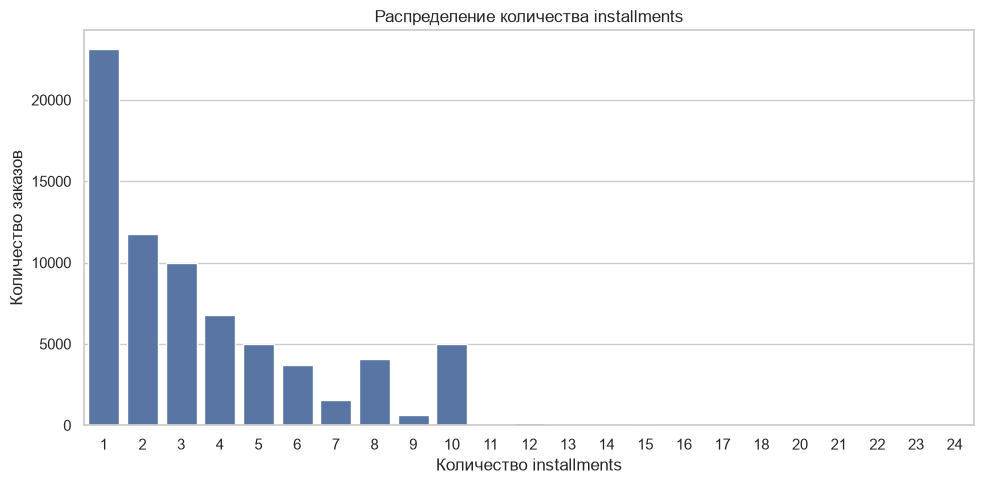

In [81]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=installment_distribution,
    x="installments",
    y="orders",
)

plt.title(
    "Распределение количества installments"
)
plt.xlabel("Количество installments")
plt.ylabel("Количество заказов")

plt.tight_layout()
plt.show()

In [82]:
main_installment_orders = (
    installment_orders[
        installment_orders["installments"] <= 10
    ]
    .copy()
)

In [83]:
installment_gmv_p99 = (
    main_installment_orders["product_gmv"]
    .quantile(0.99)
)

Для читаемости boxplot ограничен значениями от 1 до 10 installments, поскольку более высокие значения встречаются редко. Редкие категории сохраняются в полном распределении и учитываются при расчёте корреляции.

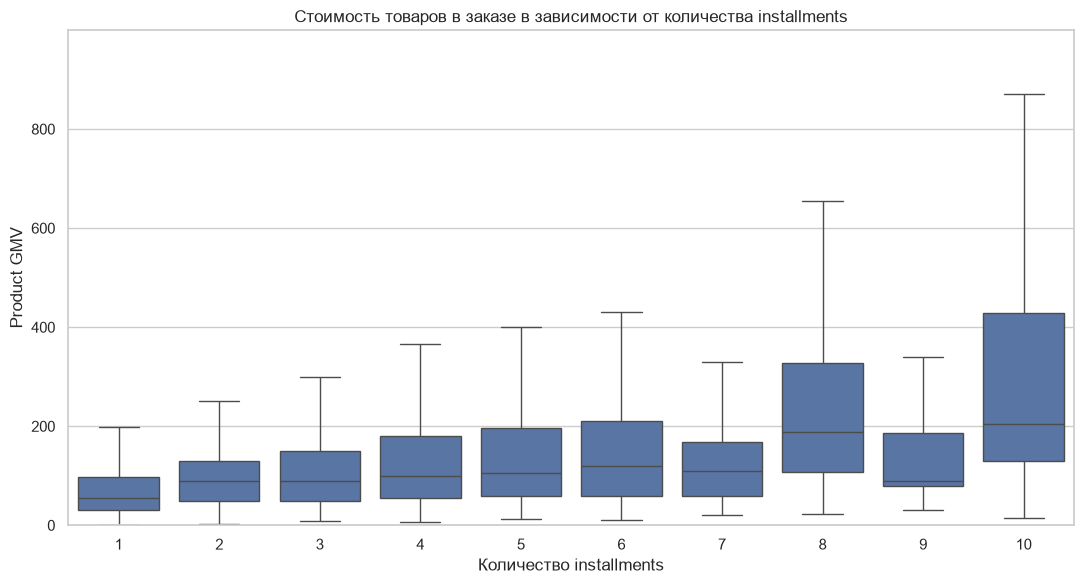

In [84]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=main_installment_orders,
    x="installments",
    y="product_gmv",
    showfliers=False,
)

plt.ylim(0, installment_gmv_p99)

plt.title(
    "Стоимость товаров в заказе "
    "в зависимости от количества installments"
)
plt.xlabel("Количество installments")
plt.ylabel("Product GMV")

plt.tight_layout()
plt.show()

In [85]:
installment_value_summary = (
    installment_orders
    .groupby(
        "installments",
        as_index=False,
    )
    .agg(
        orders=("order_id", "count"),
        median_product_gmv=(
            "product_gmv",
            "median",
        ),
    )
)

installment_value_summary

,installments,orders,median_product_gmv
0,1,23113,55.00
1,2,11769,89.99
2,3,9950,90.00
3,4,6752,99.00
4,5,4991,106.00
5,6,3722,119.90
6,7,1534,109.99
7,8,4061,189.00
8,9,608,89.90
9,10,5024,205.00


In [86]:
installment_value_main = (
    installment_value_summary[
        installment_value_summary[
            "installments"
        ] <= 10
    ]
)

Для визуализации основной тенденции используются значения от 1 до 10 installments. Более высокие значения представлены малым числом заказов и сохраняются только в полной сводной таблице и корреляционном анализе.

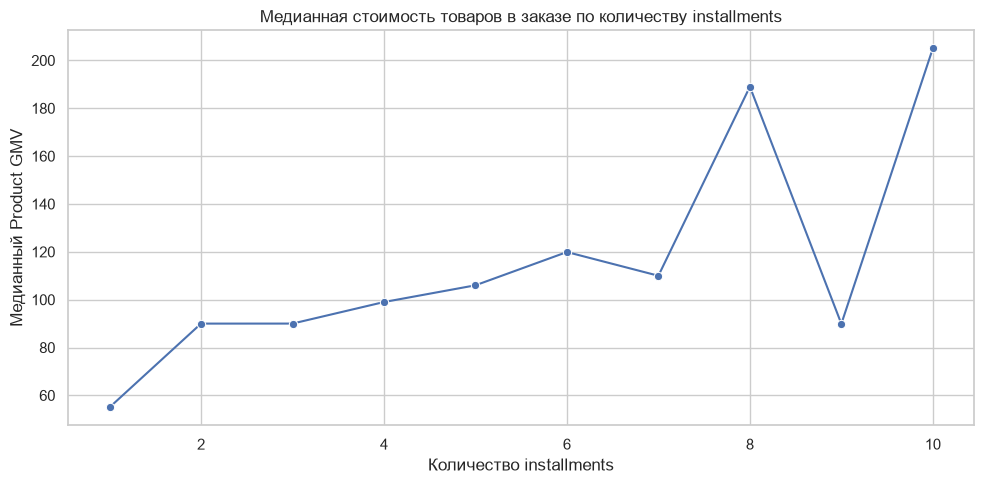

In [87]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=installment_value_main,
    x="installments",
    y="median_product_gmv",
    marker="o",
)

plt.title(
    "Медианная стоимость товаров в заказе "
    "по количеству installments"
)
plt.xlabel("Количество installments")
plt.ylabel("Медианный Product GMV")

plt.tight_layout()
plt.show()

In [88]:
installment_value_corr = (
    installment_orders[
        [
            "installments",
            "product_gmv",
        ]
    ]
    .corr(method="spearman")
    .loc[
        "installments",
        "product_gmv",
    ]
)

installment_value_corr

np.float64(0.4485570792196427)

### Наблюдения

- Анализ проводится по 71 841 доставленному заказу с одной валидной платежной записью по кредитной карте, что позволяет однозначно сопоставить количество installments со стоимостью товаров всего заказа.
- Основная часть заказов использует от 1 до 10 installments; значения выше 10 встречаются значительно реже.
- Медианная стоимость товаров в заказе в целом выше при большем количестве installments, однако зависимость не является строго монотонной: между отдельными категориями наблюдаются заметные колебания.
- Корреляция Спирмена между количеством installments и `product_gmv` составляет около 0.45, что соответствует умеренной положительной монотонной связи.
- Полученная связь не позволяет установить причинность: более дорогие покупки могут чаще разбиваться на большее количество installments, однако по данным EDA нельзя утверждать, что увеличение числа installments само по себе приводит к росту стоимости товаров в заказе.
- Результаты относятся к заказам с одной платежной записью по кредитной карте и не обязательно распространяются на заказы с несколькими платежными записями или смешанными способами оплаты.

## 10. Гипотезы для статистического анализа

Проведённый EDA выявил несколько взаимосвязей, которые представляют интерес для дальнейшей формальной статистической проверки.

На этом этапе связи рассматриваются как ассоциации между признаками. Наблюдаемые зависимости сами по себе не позволяют делать выводы о причинности.


### 10.1 Своевременность доставки и оценка заказа

EDA показывает отрицательную связь между отклонением от ожидаемой даты доставки (`delivery_deviation_days`) и средней оценкой заказа (`avg_order_review_score`): более низкие оценки чаще соответствуют более поздней доставке относительно обещанного срока.

**Нулевая гипотеза H₀:** между отклонением от ожидаемой даты доставки и оценкой заказа отсутствует монотонная связь.

**Альтернативная гипотеза H₁:** увеличение отклонения от ожидаемой даты доставки связано со снижением оценки заказа.

Единица анализа — доставленный заказ.


### 10.2 Расстояние и стоимость доставки

На уровне `order_id × seller_id` наблюдается положительная связь между приблизительным расстоянием от продавца до покупателя (`distance_km`) и стоимостью доставки (`pair_freight_value`).

**Нулевая гипотеза H₀:** между расстоянием и стоимостью доставки отсутствует монотонная связь.

**Альтернативная гипотеза H₁:** увеличение расстояния связано с увеличением стоимости доставки.

Единица анализа — пара `order_id × seller_id` с валидными географическими координатами.


### 10.3 Расстояние и время доставки

На уровне заказа наблюдается положительная связь между расстоянием до наиболее удалённого продавца (`max_seller_distance_km`) и полным временем доставки (`delivery_time_days`).

**Нулевая гипотеза H₀:** между расстоянием до наиболее удалённого продавца и временем доставки отсутствует монотонная связь.

**Альтернативная гипотеза H₁:** увеличение расстояния до наиболее удалённого продавца связано с увеличением времени доставки.

Единица анализа — доставленный заказ с валидными координатами всех продавцов.


### 10.4 Количество installments и стоимость товаров в заказе

Для доставленных заказов с одной валидной платежной записью по кредитной карте наблюдается положительная связь между количеством installments (`installments`) и стоимостью товаров в заказе (`product_gmv`).

**Нулевая гипотеза H₀:** между количеством installments и стоимостью товаров в заказе отсутствует монотонная связь.

**Альтернативная гипотеза H₁:** большее количество installments связано с большей стоимостью товаров в заказе.

Единица анализа — доставленный заказ с одной валидной платежной записью по кредитной карте.

## 11. Итоговые наблюдения

Проведённый исследовательский анализ позволил выявить основные особенности распределений и взаимосвязи между характеристиками заказов, доставки, отзывов и оплаты.

- Распределения стоимости товаров, стоимости доставки и времени доставки имеют выраженные правые хвосты. В данных присутствуют редкие экстремальные значения, однако они не удалялись автоматически и отдельно учитывались при визуализации и проверке устойчивости результатов.

- Стоимость доставки положительно связана со стоимостью товаров в заказе. При этом относительная стоимость доставки (`freight_to_gmv_ratio`) особенно высока для дешёвых заказов и снижается с ростом `product_gmv`.

- Более длительная доставка и более сильное отклонение от ожидаемой даты связаны с более низкими оценками заказа. Корреляция Спирмена между временем доставки и оценкой составляет около -0.23, а между отклонением от ожидаемой даты и оценкой — около -0.18.

- Отзывы с низкими оценками значительно чаще содержат текстовый комментарий: пользователи чаще дополняют низкую оценку текстовым отзывом.

- Географическое расстояние является одним из наиболее заметно связанных с логистикой признаков. Корреляция Спирмена между расстоянием и стоимостью доставки составляет около 0.58, а между расстоянием до наиболее удалённого продавца и временем доставки — около 0.54.

- Связь расстояния с отклонением от обещанной даты значительно слабее и отрицательна — около -0.18. Таким образом, более удалённые заказы обычно доставляются дольше, но это не сопровождается пропорциональным увеличением опоздания относительно ожидаемой даты.

- Географические результаты устойчивы к экстремальным значениям: исключение верхнего 1% расстояний практически не изменяет рассчитанные коэффициенты корреляции.

- Для доставленных заказов с одной валидной платежной записью по кредитной карте наблюдается умеренная положительная связь между количеством installments и стоимостью товаров в заказе: корреляция Спирмена составляет около 0.45. Более дорогие покупки чаще связаны с большим количеством installments, однако эта зависимость не позволяет делать причинные выводы.

Сформулированные на основе EDA гипотезы будут проверены на следующем этапе статистического анализа.